In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)
os.path.join(path, "AB_NYC_2019.csv")
df=pd.read_csv(os.path.join(path, "AB_NYC_2019.csv"))

c:\Users\Dhruv\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.44M/2.44M [00:01<00:00, 1.29MB/s]

Extracting files...


Path to dataset files: C:\Users\Dhruv\.cache\kagglehub\datasets\dgomonov\new-york-city-airbnb-open-data\versions\3


In [3]:
df.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21,0.99,1,0
9,5238,Cute & Cozy Lower East Side 1 bdrm,7549,Ben,Manhattan,Chinatown,40.71344,-73.99037,Entire home/apt,150,1,160,2019-06-09,1.33,4,188


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [5]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [6]:
df.shape

(48895, 16)

In [7]:
#Missing values
missing=df.isnull().sum()
missing[missing>0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

In [8]:
#checking biasness
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

<Axes: xlabel='room_type', ylabel='count'>

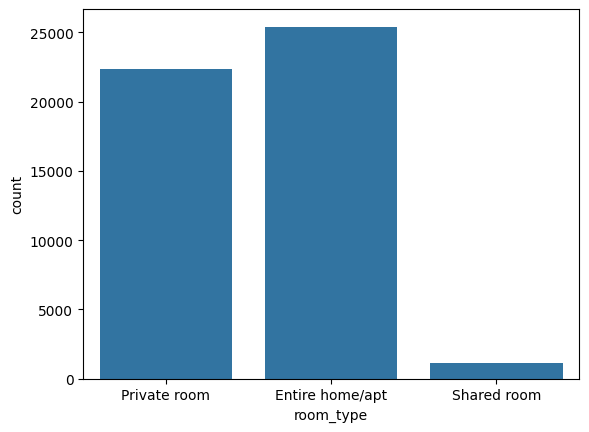

In [9]:
sns.countplot(x='room_type',data=df)

The Classses are imbalance-shared room is minority amongst others


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

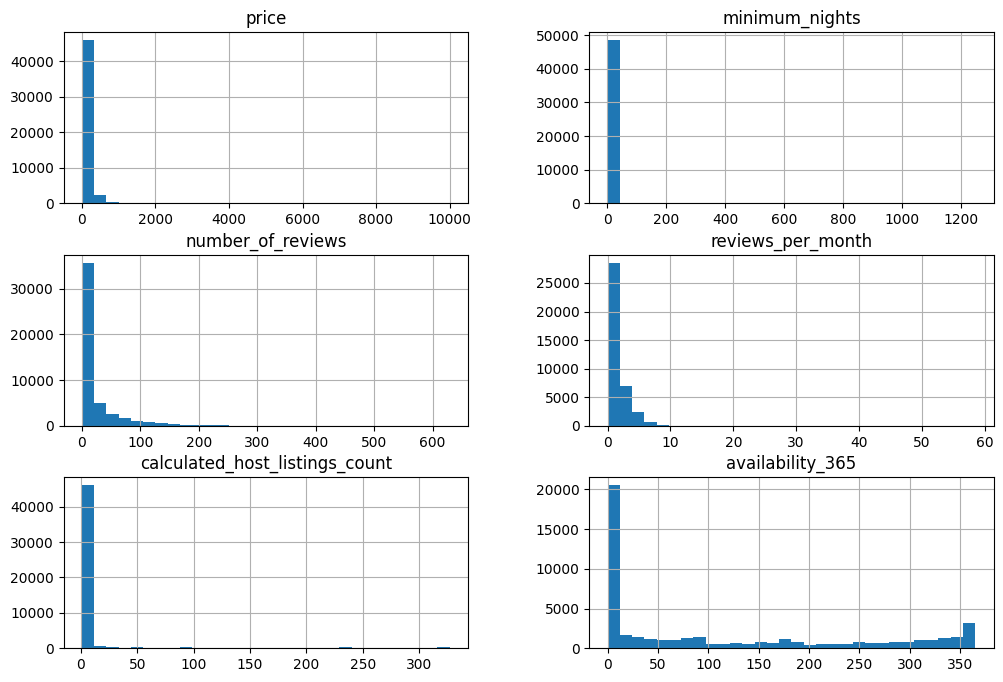

In [10]:
numerical_cols = ["price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]

df[numerical_cols].hist(bins=30, figsize=(12, 8))

<Axes: xlabel='neighbourhood_group', ylabel='count'>

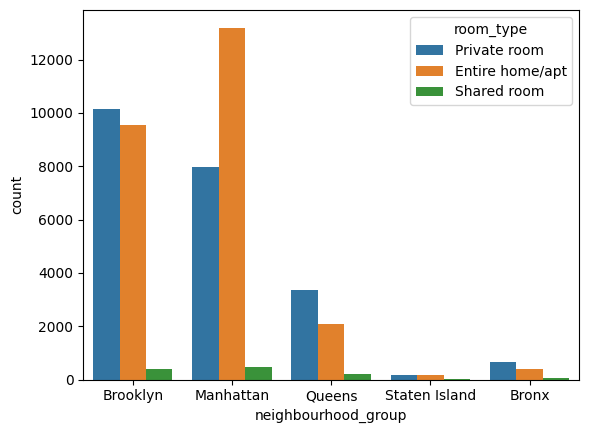

In [11]:
sns.countplot(data=df,x='neighbourhood_group',hue='room_type')

Bivariate Analysis


<Axes: xlabel='room_type', ylabel='price'>

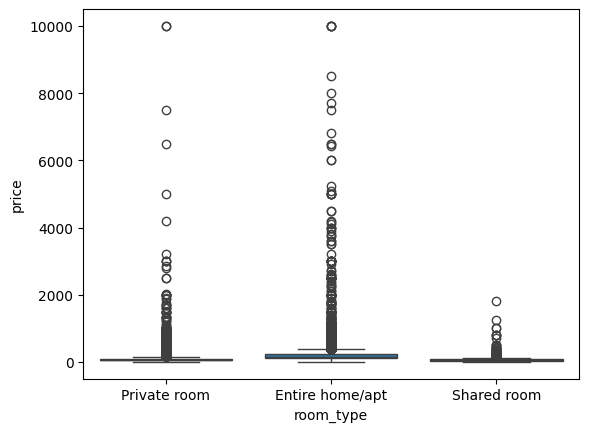

In [12]:
sns.boxplot(x='room_type',y='price' ,data=df)

correlation between numeric features

<Axes: >

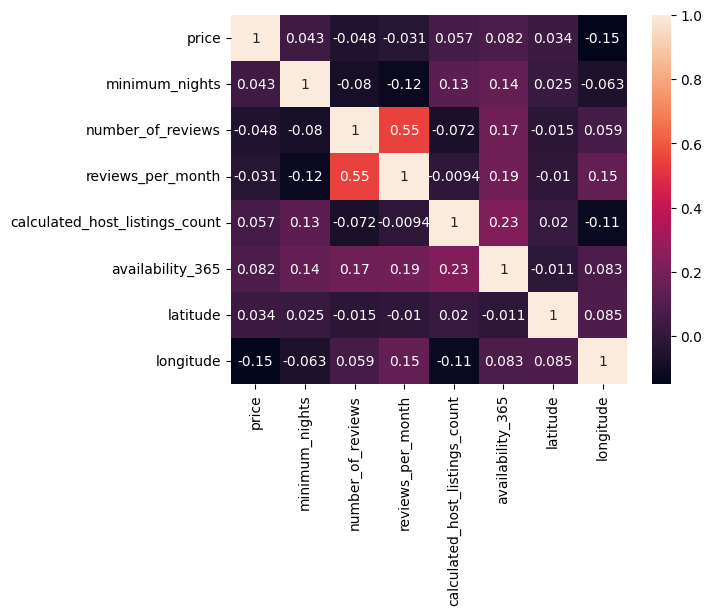

In [13]:
corr = df[numerical_cols + ['latitude', 'longitude']].corr()
sns.heatmap(corr,annot=True)

Geographic Distribution

<Axes: xlabel='longitude', ylabel='latitude'>

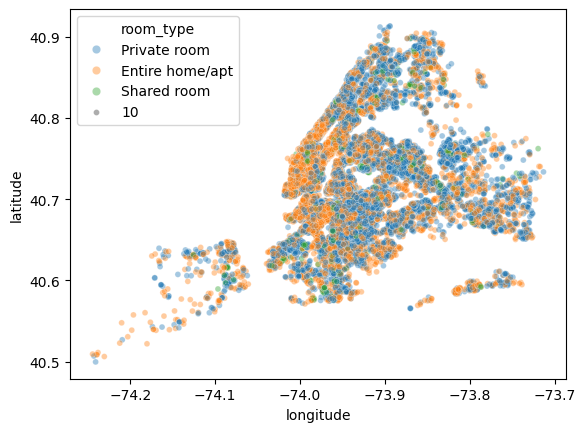

In [14]:
sns.scatterplot(x='longitude',y='latitude',data=df,hue='room_type',alpha=0.4,size=10)

Data Cleaning


In [15]:
#remove null values ,clipping,seperate features ,outliers

In [16]:
#1. Drop cols that dont help model|
df_clean=df.drop(columns=['name','host_name','last_review','host_id','id'])

In [17]:
#2. No reviews yet -> 0 reviews per month , not missing
df_clean['reviews_per_month']=df_clean['reviews_per_month'].fillna(0,inplace=True)

C:\Users\Dhruv\AppData\Local\Temp\ipykernel_8164\4049028461.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['reviews_per_month']=df_clean['reviews_per_month'].fillna(0,inplace=True)


In [18]:
#3. cap extreme outliers in price and min_nights using percentile clipping instead of deleting rows
price_cap=df_clean['price'].quantile(0.99)
nights_cap=df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)

df_clean
# """ #works same
# df_clean=df_clean[df_clean['minimum_nights']<nights_cap]
# df_clean=df_clean[df_clean['price']<price_cap]"""



,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,None,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,None,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,None,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,None,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,None,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,None,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,None,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,None,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,None,6,2


In [19]:
x=df_clean.drop(columns=['room_type'])
y=df_clean['room_type']

Train / Test Split

In [20]:
#using stratisfy = y bcoz there is imbalance in target data also use stratisfy in classfication problems
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

Preprocessing : columnTransformer + Pipeline

In [21]:
# numeric features -> median imputation + standard scaling
#categorical -> most frequeent imputation + one_hot encoding

In [22]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder , PowerTransformer
from sklearn.compose import ColumnTransformer

In [23]:
numerical_cols=  ['latitude', 'longitude',"price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]
categorical_cols=['neighbourhood_group','neighbourhood']

In [24]:
#1. Pipeline - > numeric cols
numerical_pipeline = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),

        ('scaler',StandardScaler())
    ]
)
#2. Pipeline -> categorical cols
categorical_pipeline = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehot',OneHotEncoder(handle_unknown='ignore'))
    ]
)
#3.Pipeline ->  columnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num',numerical_pipeline , numerical_cols),
        ('cat',categorical_pipeline,categorical_cols)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['latitude', 'longitude', 'price',
                                  'minimum_nights', 'number_of_reviews',
                                  'reviews_per_month',
                                  'calculated_host_listings_count',
                                  'availability_365']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['neighbourhood_group', 'neighbourhood'])])

For class imbalance we use mostly -
SMOTE [ synthetic minority oversampling ]
But not gonna use it here

-----------------------------------------
drawbacks
1 . Overfitting
2. data leakage



Another method to fill the class imbalance

**Class Weight**

Minority class will be focused much more then the majority one's

Multiple Algorithms for training

1. Logistic regression
2. decision tree
3. random forest

all will have weight class

4. gradient boosting

disadvantage of class weight - > not all model support this alogirthm (example: gradient boosting)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_validate , cross_val_score
import warnings
warnings.filterwarnings('ignore')

class weight = balance means model has to pay more attention on the minority class or rare class. here it is "shared room"

In [26]:
models={
    'logistic':LogisticRegression(class_weight='balanced',random_state=42),
    'decision':DecisionTreeClassifier(class_weight='balanced',random_state=42),
    'random':RandomForestClassifier(class_weight='balanced',random_state=42),
    'gradient':GradientBoostingClassifier(random_state=42)
}

for name , model in models.items():
  pipe = Pipeline(steps=[
      ('preprocessor',preprocessor),
      ('classifier',model)
  ])
  #accuracy alone can be misleading on imbalanced classes, so we use macro f1
  #both plain accuracy and macro f1 score which treats every class equally
  accuracy = cross_val_score(pipe ,x_train, y_train ,cv=4,scoring="accuracy")
  macrof1 = cross_val_score(pipe ,x_train, y_train ,cv=4,scoring="f1_macro")
  print(f"{name}->Accuracy : {accuracy.mean():.3f}, F1: {macrof1.mean():.3f}")

logistic->Accuracy : 0.662, F1: 0.526
decision->Accuracy : 0.787, F1: 0.660
random->Accuracy : 0.854, F1: 0.725
gradient->Accuracy : 0.850, F1: 0.706


Best model is randomforest

now we gonna do hyperparamater tunining

In [27]:
from sklearn.model_selection import RandomizedSearchCV
best_pipeline = Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('classifier',RandomForestClassifier(class_weight='balanced',random_state=42))
    ]
)
param_dist = {
    'classifier__n_estimators':[100,200,150],
    'classifier__max_depth':[5,10,15],
    'classifier__min_samples_split':[2,5,10],
    'classifier__min_samples_leaf':[1,2,4],
    'classifier__max_features':['sqrt','log2',None]
}
search=RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='f1_macro',
    verbose=1,
    random_state=42,
    n_jobs=-1
)
search.fit(x_train,y_train)


Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['latitude',
                                                                                'longitude',
                                                                                'price',
                                                                                'minimum_nights',
                                                                                'number_of_reviews',
                                                                                'reviews_per_month',
                                                                                'calculated_host_listings_count',
                                                                                'availability_365']),
                                                                              ('cat',
                                                                               Pipe...
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__max_depth': [5, 10, 15],
                                        'classifier__max_features': ['sqrt',
                                                                     'log2',
                                                                     None],
                                        'classifier__min_samples_leaf': [1, 2,
                                                                         4],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     150]},
                   random_state=42, scoring='f1_macro', verbose=1)

In [28]:
print("best Paramter: ", search.best_params_)
print("Best Score: ", search.best_score_)

best Paramter:  {'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_features': None, 'classifier__max_depth': 15}
Best Score:  0.7398105997777209


Final Evaluation


In [29]:
from sklearn.metrics import accuracy_score,classification_report,f1_score,confusion_matrix
best_model = search.best_estimator_
y_pred = best_model.predict(x_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print("f1score: ",f1_score(y_test,y_pred,average='macro'))
print("accuracy: ",accuracy_score(y_test,y_pred))

                 precision    recall  f1-score   support

Entire home/apt       0.88      0.88      0.88      5082
   Private room       0.84      0.85      0.85      4465
    Shared room       0.62      0.47      0.53       232

       accuracy                           0.86      9779
      macro avg       0.78      0.73      0.75      9779
   weighted avg       0.85      0.86      0.86      9779

[[4476  600    6]
 [ 615 3790   60]
 [  23  101  108]]
f1score:  0.7521236852442525
accuracy:  0.8563247775846201


<Axes: >

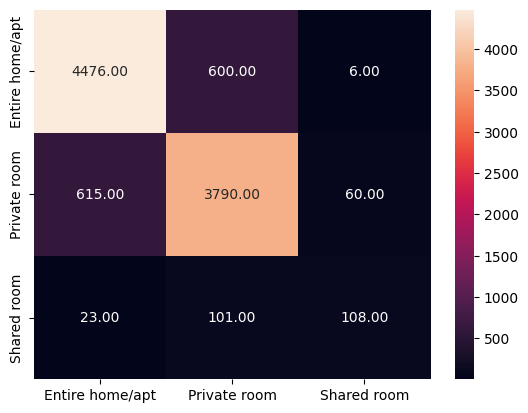

In [30]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt=".2f",
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)

Save the model

In [39]:
import joblib

joblib.dump(
    best_pipeline,
    "model_Pipeline.pkl",
    compress=3
)


['model_Pipeline.pkl']

In [33]:
import os
import joblib

model_path = "model_Pipeline.pkl"

joblib.dump(search.best_estimator_, model_path, compress=3)

print("File exists:", os.path.exists(model_path))
print("File path:", os.path.abspath(model_path))
print("File size (bytes):", os.path.getsize(model_path))
print("File size (MB):", os.path.getsize(model_path) / (1024 * 1024))

File exists: True
File path: c:\Users\Dhruv\OneDrive\Desktop\ml_room_classification\Classification Project\model_Pipeline.pkl
File size (bytes): 18132630
File size (MB): 17.29262351989746


In [32]:
import os

size = os.path.getsize("model_Pipeline.pkl") / (1024 * 1024)

print(f"Model size: {size:.2f} MB")

Model size: 0.00 MB


In [34]:
import joblib

loaded_model = joblib.load("model_Pipeline.pkl")

print("Model loaded successfully!")
print(type(loaded_model))

Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [35]:
predictions = loaded_model.predict(x_test.iloc[:5])

print(predictions)

['Private room' 'Private room' 'Entire home/apt' 'Private room'
 'Entire home/apt']


In [36]:
probabilities = loaded_model.predict_proba(x_test.iloc[:5])

print(probabilities)

[[0.02543629 0.88462476 0.08993895]
 [0.31086109 0.67133918 0.01779973]
 [0.9306809  0.0693191  0.        ]
 [0.07574871 0.84947425 0.07477704]
 [0.64991749 0.33659273 0.01348978]]


In [37]:
print(loaded_model.named_steps["classifier"])

RandomForestClassifier(class_weight='balanced', max_depth=15, max_features=None,
                       min_samples_leaf=4, min_samples_split=5,
                       n_estimators=200, random_state=42)
